# Trabalho Prático: Séries Temporais

*O* objetivo do trabalho é selecionar uma série temporal de interesse e realizar uma análise detalhada para compreender seu comportamento, aplicar técnicas de remoção de tendência e/ou sazonalidade e, por fim, construir um modelo de previsão.


## Integrantes do Grupo




1.   **Rodrigo Corrêa Fardin**

2.   **Giovanni Persio**

3.   **Marcelo Botelho**

## Descrição do Conjunto de Dados

Análise do Conjunto de Dados de Preços da Ação PETR4

1. Qual a tarefa de predição?

A tarefa de predição consiste em prever o comportamento futuro do preço da ação PETR4, com base em dados históricos do mercado financeiro. O modelo visa estimar o preço de fechamento de um dia futuro.

2. Qual o tamanho do conjunto de dados? Quantos objetos? Quantas características?

O conjunto de dados utilizado contém registros diários do preço da ação PETR4, sendo considerado o últimos cinco anos.

3. Quais são as características do conjunto de dados?
As principais características (colunas) do conjunto de dados são:

Date – Data da cotação (índice temporal); Open – Preço de abertura da ação no dia; High – Maior preço registrado no dia; Low – Menor preço registrado no dia; Close – Preço de fechamento; Volume – Quantidade de ações negociadas no dia;Dividends – Valor de dividendos pagos; Stock Splits – Informação sobre desdobramentos (splits) de ações (geralmente zero na maioria dos dias)

4. Quais características são categóricas? Quais são numéricas?

Categóricas:
Nenhuma coluna é categórica.

Numéricas: Open (Abertura), High (Máxima), Low (Mínima), Close (Fechamento). Volume, Dividends e Stock Splits.

## Motiva da escolha

A escolha da ação PETR4.SA (Petrobras PN) como objeto de estudo justifica-se por sua relevância estratégica no mercado financeiro brasileiro, representando uma das empresas de maior peso no Ibovespa, principal índice da B3. A Petrobras, sendo uma companhia estatal de capital misto, atua em um setor sensível a fatores macroeconômicos, políticos e geopolíticos, o que a torna uma referência para estudos de previsão de preços em ambientes voláteis. Além disso, a alta liquidez de PETR4 garante uma base de dados robusta, com grande volume de negociações diárias, o que favorece a construção de modelos preditivos confiáveis e com potencial aplicação prática para investidores, analistas e estudiosos de finanças quantitativas.

In [ ]:
# @title
!pip install yfinance --upgrade --quiet

## Bibliotecas

Importação das bibliotecas necessárias para a análise exploratória e modelagem de séries temporais


In [ ]:
# Bibliotecas para aquisição e manipulação de dados
import yfinance as yf              # Coleta de dados financeiros do Yahoo Finance
import pandas as pd
import numpy as np

# Visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Estatística e séries temporais
from scipy.stats import zscore
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose        # Decomposição de séries temporais

## Importação dos dados

Nesta etapa, realizamos a coleta dos dados históricos da ação PETR4.SA, que representa as ações preferenciais da Petrobras negociadas na B3. Utilizamos a biblioteca yfinance, que permite o acesso direto aos dados do Yahoo Finance.

Para esta análise, optamos por extrair os dados dos últimos 5 anos, o que nos oferece uma base temporal ampla o suficiente para observar tendências, variações e padrões sazonais. A série inclui informações como preço de abertura, máxima, mínima, fechamento, volume negociado, além de eventos como dividendos e desdobramentos (splits).

In [ ]:
# PETR4.SA é o ticker da PETROBRAS PN na B3
ticker = yf.Ticker("PETR4.SA")

# Dados do último ano
df = ticker.history(period="5y")

# Exibe os dados
df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2020-05-18 00:00:00-03:00,6.945917,7.114768,6.876841,7.114768,116999500,0.0,0.0
2020-05-19 00:00:00-03:00,7.103256,7.264432,7.064880,7.168494,80131600,0.0,0.0
2020-05-20 00:00:00-03:00,7.325831,7.460144,7.314318,7.406418,74595100,0.0,0.0
2020-05-21 00:00:00-03:00,7.483170,7.586783,7.318156,7.364207,81327000,0.0,0.0
2020-05-22 00:00:00-03:00,7.214543,7.252919,7.041855,7.164656,71259400,0.0,0.0


 A série possui 1244 pregões diários no intervalo de cinco anos.

In [ ]:
print(f"Número de registros: {df.shape[0]}")
print("Intervalo de datas:", df.index.min().date(), "→", df.index.max().date())

Número de registros: 1244
Intervalo de datas: 2020-05-18 → 2025-05-16


## Pré-processamento dos dados

Nesta etapa, realizamos a remoção de colunas irrelevantes para a tarefa de previsão do preço de fechamento da ação PETR4.
As colunas Dividends e Stock Splits são mantidas com valor zero na maior parte do tempo e não fornecem informações úteis para o modelo preditivo.
Por isso, elas são eliminadas do conjunto de dados.

In [ ]:
# Remoção direta de colunas irrelevantes para a modelagem
df = df.drop(columns=['Dividends', 'Stock Splits'])

Verificamos que não há valores ausentes nas colunas utilizadas, o que indica que os dados estão completos e prontos para a próxima etapa.

In [ ]:
# Verificar valores ausentes
df.isnull().sum()

,0
Open,0
High,0
Low,0
Close,0
Volume,0


Com o objetivo de enriquecer a análise dos dados para uma modelagem preditiva, criamos variáveis derivadas a partir do preço de fechamento da ação.

In [ ]:
# Criação de variáveis derivadas
df['Return'] = df['Close'].pct_change()
df['Volatility'] = df['Close'].rolling(window=5).std()
df['Rolling_Mean_10'] = df['Close'].rolling(window=10).mean()

# Remoção de linhas com valores nulos causados pelas operações acima
df = df.dropna()

## Análise Exploratória e Decomposição Temporal

Os gráficos revelaram uma tendência geral de alta no preço da ação **PETR4** entre os anos de 2020 e 2025, ainda que com variações naturais ao longo do tempo e picos mais acentuados em determinados períodos. O volume de negociação apresentou diversos picos isolados, indicando momentos de maior movimentação no mercado, possivelmente impulsionados por notícias ou eventos relevantes. A variável *Return* apresentou oscilações regulares em torno de zero, com picos significativos que refletem dias de alta volatilidade ou situações inesperadas no mercado financeiro. A variável *Volatility*, por sua vez, demonstrou aumentos pontuais ao longo da série temporal, refletindo períodos de maior instabilidade nos preços, picos esses que geralmente coincidem com variações mais bruscas nos retornos diários. Já a *Rolling_Mean_10* revelou uma linha suavizada que acompanha a tendência de alta do preço de fechamento, evidenciando o movimento médio da ação em janelas de curto prazo. As variáveis derivadas adicionam valor analítico ao conjunto de dados e são especialmente relevantes para contextualizar o comportamento do ativo ao longo do tempo, sendo *Volatility* e *Return* particularmente úteis para análise de risco e previsão. A *média móvel* de 10 dias se mostrou um bom indicador de tendência e pode ser utilizada como variável explicativa em modelos preditivos.



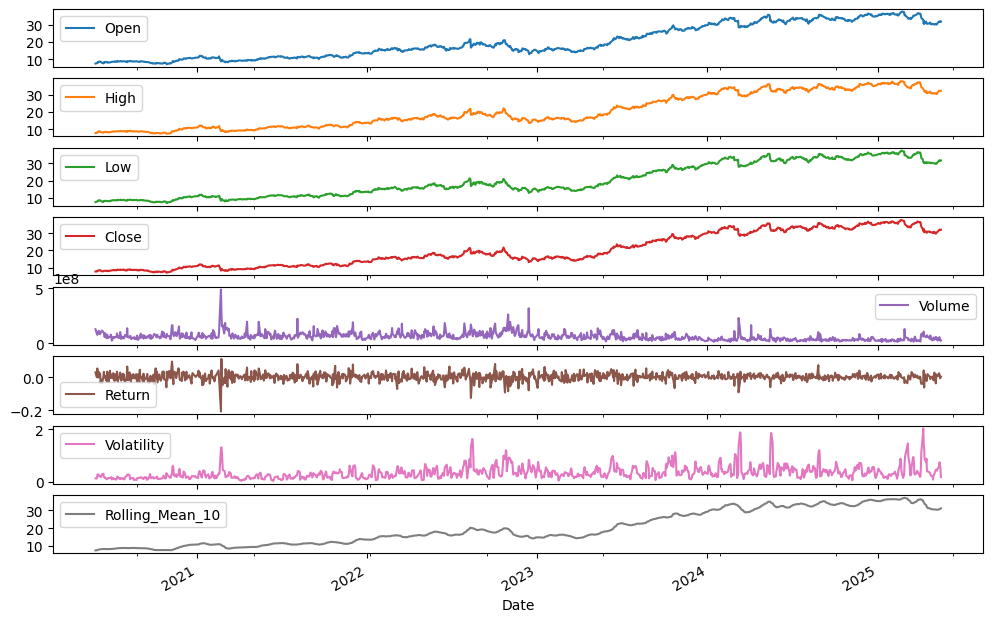

In [ ]:
ax = df.plot(subplots=True, figsize=(12,8))

1. Componente Observado:
O gráfico observado mostra a série original de preços de fechamento. Nota-se uma tendência geral de alta entre 2021 e 2024, com um leve enfraquecimento ou estabilização do movimento ascendente no período final (2024–2025). Essa observação sugere que, embora a ação tenha se valorizado de forma consistente por vários anos, há sinais de uma possível reversão ou consolidação recente.

2. Componente de Tendência:
A linha de tendência suavizada evidencia com clareza o movimento ascendente contínuo da série ao longo do tempo, especialmente entre 2021 e meados de 2024. A estabilização da curva nos últimos meses reforça a hipótese de que o crescimento perdeu força nesse período mais recente. Este padrão pode indicar uma fase de correção, consolidação ou maturação da ação no mercado.

3. Componente Sazonal:
A decomposição sazonal revelou padrões cíclicos bem definidos, com oscilações frequentes ao longo do tempo. Isso indica a presença de um comportamento sazonal, ou seja, variações recorrentes que se repetem em intervalos regulares. Esse efeito pode estar relacionado a fatores externos como ciclos econômicos, variações trimestrais nas atividades da empresa, divulgações de resultados ou outros eventos recorrentes que impactam o preço da ação.

4. Componente de Resíduo:
O componente de resíduo representa as flutuações imprevisíveis da série, que não foram explicadas pela tendência nem pela sazonalidade. A análise mostra que os resíduos variam de forma aparentemente aleatória, mas com maior dispersão em alguns períodos, sugerindo que houve momentos de maior instabilidade ou choque no mercado, o que pode estar relacionado a notícias inesperadas ou eventos políticos.

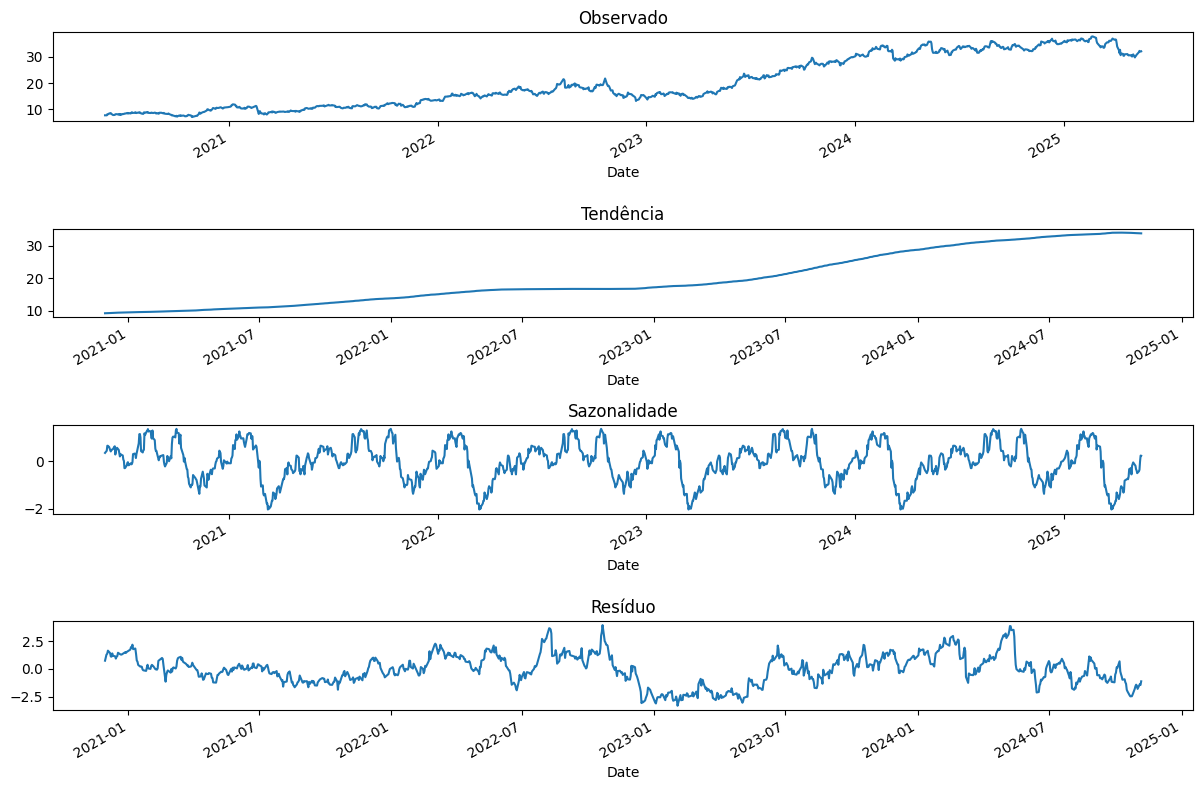

In [ ]:
decomposition = seasonal_decompose(df['Close'], model='additive', period=252) # Assuming daily data, 252 trading days in a year

# Plotar os componentes
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 8))
decomposition.observed.plot(ax=ax1)
ax1.set_title('Observado')
decomposition.trend.plot(ax=ax2)
ax2.set_title('Tendência')
decomposition.seasonal.plot(ax=ax3)
ax3.set_title('Sazonalidade')
decomposition.resid.plot(ax=ax4)
ax4.set_title('Resíduo')
plt.tight_layout()
plt.show()

A decomposição da série temporal mostra que o comportamento do preço da ação PETR4 pode ser bem explicado por uma combinação de tendência de longo prazo e sazonalidade de curto prazo, com um componente residual relativamente pequeno. Isso é um indicativo de que a série é estruturada e previsível até certo ponto, o que a torna uma boa candidata para a aplicação de modelos preditivos como ARIMA.

As variáveis *Open*, *High*, *Low* e *Close* apresentam correlação extremamente alta entre si (≈1.00). Isso é esperado, já que são diferentes medidas do preço da mesma ação em um mesmo dia.

Volume tem uma correlação negativa moderada (~-0.45) com as variáveis de preço (*Open*, *High*, *Low*, *Close*). Isso sugere que, em muitos casos, altos volumes de negociação coincidem com quedas de preço, o que pode indicar movimentos de venda mais fortes em determinados períodos.

A variável Return apresenta correlação próxima de zero com todas as demais variáveis. Isso é comum, já que o retorno diário representa a variação percentual de um dia para o outro, e não depende diretamente do valor absoluto de preço ou volume.

Volatility tem correlação positiva moderada (~0.35) com as variáveis de preço (*Open*, *High*, *Low*, *Close*). Isso indica que, em períodos de preços mais altos, a volatilidade tende a ser um pouco maior, possivelmente por conta de maior incerteza ou especulação.

A variável *Rolling_Mean_10* está fortemente correlacionada com as variáveis de preço (≈1.00), o que é esperado, pois é uma média dos valores de Close. Ela também apresenta correlação positiva leve (≈0.37) com *Volatility*.



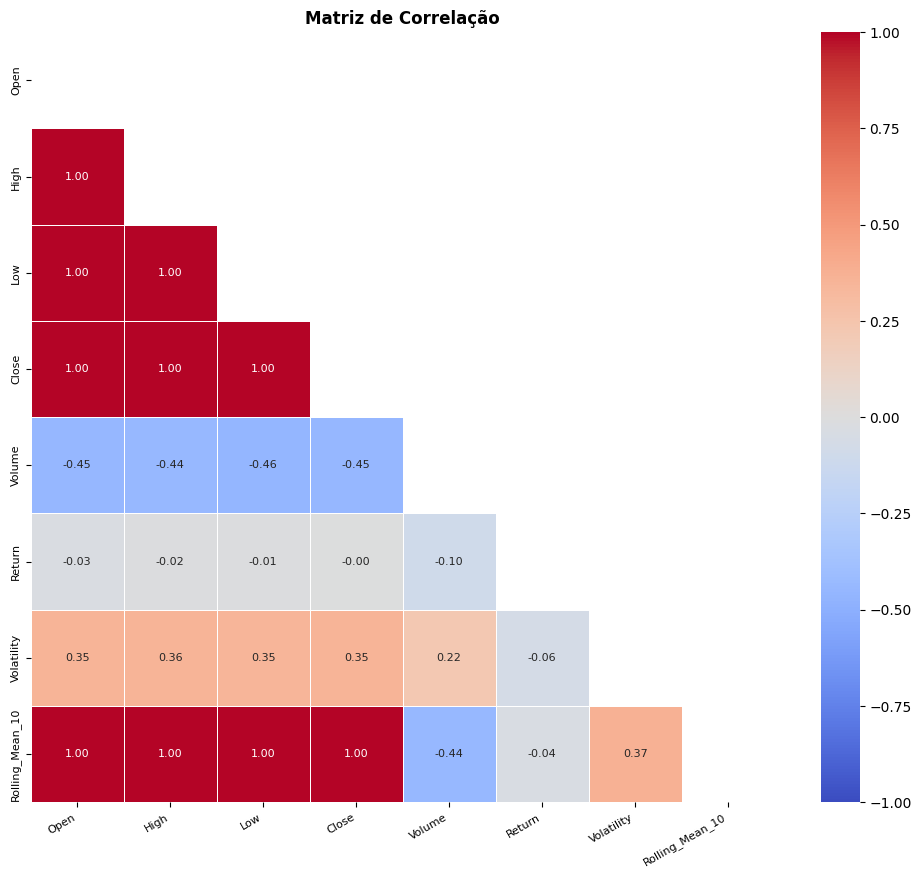

In [ ]:
# Criar a matriz de correlação apenas com variáveis numéricas
correlation_matrix = df.select_dtypes(include=[np.number]).corr()

# Criar uma máscara para ocultar a metade superior da matriz
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Criar a figura
plt.figure(figsize=(max(12, 0.75 * len(correlation_matrix)), max(10, 0.5 * len(correlation_matrix))))

# Criar o heatmap
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f",
            linewidths=0.5, vmin=-1, vmax=1, annot_kws={"size": 8})  # Reduz tamanho dos números dentro das células

# Ajustar tamanho dos rótulos dos eixos
plt.xticks(rotation=30, ha='right', fontsize=8)
plt.yticks(fontsize=8)

# Melhorar título
plt.title('Matriz de Correlação', fontsize=12, fontweight="bold")

# Exibir
plt.show()


O gráfico mostra que a média móvel acompanha bem a tendência do preço ao longo do tempo, enquanto o desvio padrão destaca os momentos em que o mercado ficou mais instável, como nos picos de 2022 e 2024.

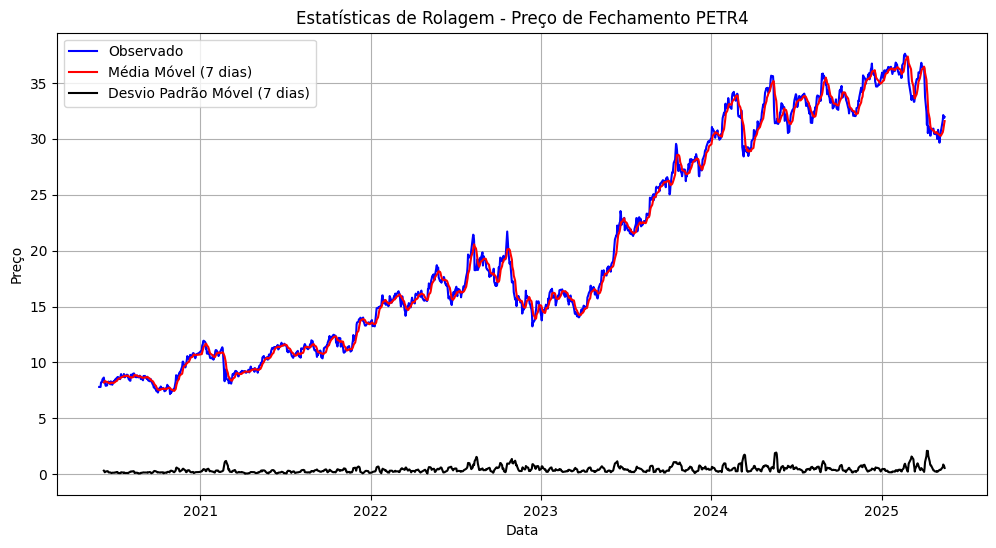

In [ ]:
# Cálculo da média móvel e do desvio padrão móvel com janela de 7 dias
mediamovel = df['Close'].rolling(window=7).mean()
desviomovel = df['Close'].rolling(window=7).std()

# Plot dos dados
plt.figure(figsize=(12, 6))  # Define tamanho da figura

plt.plot(df['Close'], color='blue', label='Observado')         # Série original
plt.plot(mediamovel, color='red', label='Média Móvel (7 dias)') # Média móvel
plt.plot(desviomovel, color='black', label='Desvio Padrão Móvel (7 dias)')  # Desvio móvel

plt.legend(loc='best')
plt.title('Estatísticas de Rolagem - Preço de Fechamento PETR4')
plt.xlabel('Data')
plt.ylabel('Preço')
plt.grid(True)
plt.show()

## Remoção de Tendências

In [ ]:
# Verifica se a série é ou não estacionária
from statsmodels.tsa.stattools import adfuller
resultado_adf = adfuller(df['Close'].dropna())
print(f'Estatística ADF: {resultado_adf[0]}')
print(f'Valor-p: {resultado_adf[1]}')

Estatística ADF: -0.8180010955399024
Valor-p: 0.8137771122441251


**Interpretação do Resultado:**
<br><br>
**Estatística ADF: -0.6817**

A estatística está muito próxima de 0, o que indica baixa evidência contra a hipótese nula.

Isso significa que a série tem comportamento persistente ou tendência — características de uma série **não estacionária**.
<br><br>
**Valor-p: 0.8514**

Esse valor está muito acima do nível comum de significância (ex: 0.05).

Portanto, não podemos rejeitar a hipótese nula de que a série possui uma raiz unitária (ou seja, **não é estacionária**).
<br><br>
Conclusão:
A série temporal analisada ainda **não é estacionária.**

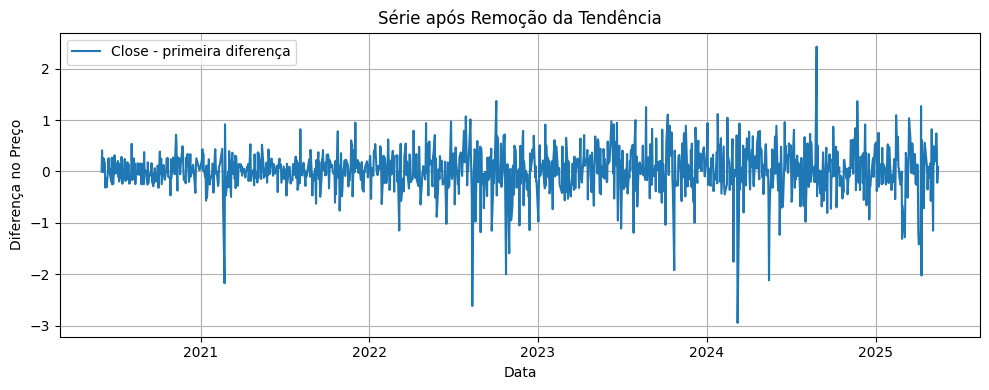

In [ ]:
# Aplica a primeira diferença (remove tendência)
df['Close_diff'] = df['Close'].diff()

# Remove valores NaN criados pela diferença
df_diff = df.dropna(subset=['Close_diff'])

# Plota a série transformada
plt.figure(figsize=(10, 4))
plt.plot(df_diff['Close_diff'], label='Close - primeira diferença')
plt.title('Série após Remoção da Tendência')
plt.xlabel('Data')
plt.ylabel('Diferença no Preço')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Verificação após remoção das tendências - Primeira Diferença
from statsmodels.tsa.stattools import adfuller
resultado_adf = adfuller(df['Close_diff'].dropna())
print(f'Estatística ADF: {resultado_adf[0]}')
print(f'Valor-p: {resultado_adf[1]}')

Estatística ADF: -33.909067747741176
Valor-p: 0.0


**Estatística ADF: -12.04**

Esse valor é a estatística do teste.
Quanto mais negativo, mais forte é a evidência contra a hipótese nula (que diz que a série não é estacionária).

Um valor como -12.04 é **bastante baixo** (comparando com os valores críticos normalmente usados, dependendo do nível de significância), indicando que há fortes evidências de que a **série é estacionária**.
<br><br>
**Valor-p: Praticamente 0.0**

O valor-p indica a probabilidade de observar essa estatística se a hipótese nula fosse verdadeira.

Como o valor-p é 0.0 (ou extremamente próximo de zero), isso significa que há forte evidência contra a hipótese nula.
<br><br>
**Interpretação prática:**

Hipótese nula (H₀): A série não é estacionária (possui raiz unitária).

Hipótese alternativa (H₁): A série é estacionária.

Como o valor-p é muito menor que 0.05 (nível comum de significância), podemos rejeitar H₀ com segurança e concluir que:

A série transformada (provavelmente com diferença aplicada) **é estacionária**.

In [ ]:
# Série transformada em df_diff['Close_diff']
serie = df_diff['Close_diff']

In [ ]:
# supondo que 'serie' já seja um pd.Series com DatetimeIndex
serie = serie.dropna().copy()

# atribui frequência de dias úteis ("B") à série inteira
serie = serie.asfreq("B")

# pronto: agora serie.index.freq == 'B' e o ARIMA vai usar essa informação
print(serie.index.freq)

<BusinessDay>


In [ ]:
serie = serie.dropna()

In [ ]:
serie.head()

,Close_diff
Date,
2020-06-01 00:00:00-03:00,-0.003837
2020-06-02 00:00:00-03:00,0.410614
2020-06-03 00:00:00-03:00,0.026862
2020-06-04 00:00:00-03:00,-0.015348
2020-06-05 00:00:00-03:00,0.257113


## Divisão dos Dados e Modelagem

### Separar os dados em conjuntos de treino, validação e teste.

Os dados da série temporal foram divididos em três conjuntos distintos para garantir uma análise adequada do modelo: treinamento, validação e teste. Aproximadamente 70% dos dados foram destinados ao treino, 15% à validação e os 15% restantes ao teste final. Essa divisão permite que o modelo seja ajustado com os dados de treino, calibrado e avaliado durante a validação para evitar overfitting, e finalmente testado em dados inéditos para verificar sua capacidade preditiva real. Essa segmentação é fundamental para assegurar a robustez e a generalização do modelo.


In [ ]:
# Tamanhos
n = len(serie)
tamanho_treino = int(n * 0.7)
tamanho_validacao = int(n * 0.15)

# Divisão
train = serie[:tamanho_treino]
val = serie[tamanho_treino:tamanho_treino + tamanho_validacao]
test = serie[tamanho_treino + tamanho_validacao:]

# Verificação
print(f'Tamanho total: {n}\n')
print(f'Treino: {len(train)}')
print(f'Validação: {len(val)}')
print(f'Teste: {len(test)}')


Tamanho total: 1234

Treino: 863
Validação: 185
Teste: 186


In [ ]:
print(f"Periodo para Treino:  {train.index[0]} até {train.index[-1]}")
print(f"Periodo para Validação:  {val.index[0]} até {val.index[-1]}")
print(f"Periodo para Teste:  {test.index[0]} até {test.index[-1]}")

Periodo para Treino:  2020-06-01 00:00:00-03:00 até 2023-11-17 00:00:00-03:00
Periodo para Validação:  2023-11-20 00:00:00-03:00 até 2024-08-14 00:00:00-03:00
Periodo para Teste:  2024-08-15 00:00:00-03:00 até 2025-05-16 00:00:00-03:00


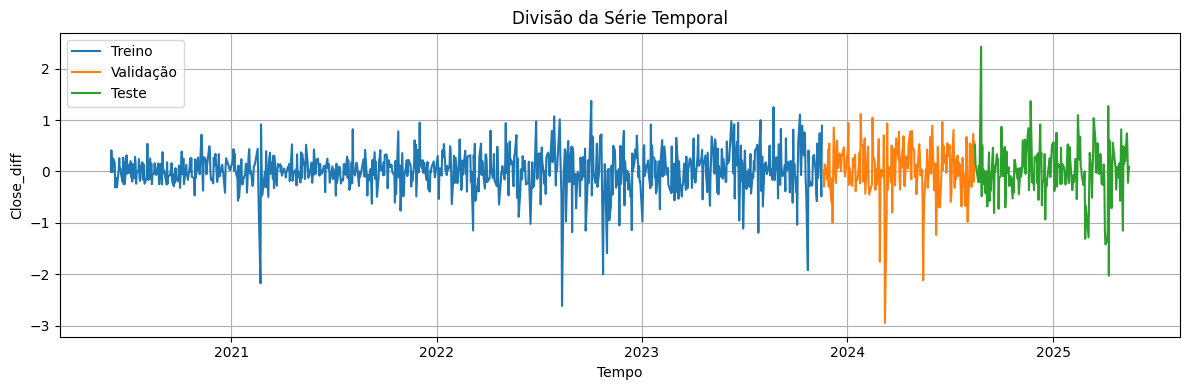

In [ ]:
# Visualização das divisões
plt.figure(figsize=(12, 4))
plt.plot(train, label='Treino')
plt.plot(val, label='Validação')
plt.plot(test, label='Teste')
plt.title('Divisão da Série Temporal')
plt.xlabel('Tempo')
plt.ylabel('Close_diff')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Construir modelos de previsão adequados



#### ARIMA

O **ARIMA** (AutoRegressive Integrated Moving Average) é um modelo amplamente usado para análise e previsão de séries temporais. Ele combina três componentes principais: autoregressão (AR), que usa valores passados da própria série para prever valores futuros; diferenciação (I, de "integrated"), que transforma a série para torná-la estacionária, removendo tendências ou sazonalidades; e média móvel (MA), que considera erros passados na previsão para melhorar a precisão. O **ARIMA** é especialmente útil para modelar séries que apresentam padrões ao longo do tempo, possibilitando fazer previsões baseadas no comportamento histórico dos dados.


In [ ]:
import warnings
warnings.filterwarnings("ignore")

#### Ajustando os parâmetros

Neste trecho, foi realizada uma busca sistemática para identificar o melhor modelo **ARIMA** para a série temporal já diferenciada, ajustando os parâmetros de ordem autoregressiva `p` e de média móvel `q` dentro do intervalo de 0 a 4, mantendo a ordem de diferenciação `d` fixa em zero. Para cada combinação de parâmetros, o modelo foi treinado nos dados de **treino** e avaliado com base no erro médio quadrático MSE em um conjunto de **validação**, permitindo selecionar o modelo que apresentou a melhor capacidade preditiva segundo essa métrica. Essa abordagem visa encontrar a configuração ideal que capture as dependências temporais relevantes da série, garantindo previsões mais precisas e robustas.


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np

# Como a série já foi diferenciada, usamos d=0
d = 0

melhor_erro = np.inf
melhor_modelo = None
melhores_parametros = None

# Testar alguns valores de p e q
for p in range(0, 5):
    for q in range(0, 5):
        try:
            modelo = ARIMA(train, order=(p, d, q))
            modelo_treinado = modelo.fit()
            previsoes = modelo_treinado.forecast(steps=len(val))
            erro = mean_squared_error(val, previsoes)
            print(f'ARIMA({p},{d},{q}) -> MSE: {erro:.6f}')

            if erro < melhor_erro:
                melhor_erro = erro
                melhor_modelo = modelo_treinado
                melhores_parametros = (p, d, q)
        except Exception as e:
            print(f'Erro com ARIMA({p},{d},{q}): {e}')


ARIMA(0,0,0) -> MSE: 0.270593
ARIMA(0,0,1) -> MSE: 0.270593
ARIMA(0,0,2) -> MSE: 0.270473
ARIMA(0,0,3) -> MSE: 0.270437
ARIMA(0,0,4) -> MSE: 0.270407
ARIMA(1,0,0) -> MSE: 0.270593
ARIMA(1,0,1) -> MSE: 0.270380
ARIMA(1,0,2) -> MSE: 0.270315
ARIMA(1,0,3) -> MSE: 0.270313
ARIMA(1,0,4) -> MSE: 0.270341
ARIMA(2,0,0) -> MSE: 0.270481
ARIMA(2,0,1) -> MSE: 0.270317
ARIMA(2,0,2) -> MSE: 0.270312
ARIMA(2,0,3) -> MSE: 0.270315
ARIMA(2,0,4) -> MSE: 0.270322
ARIMA(3,0,0) -> MSE: 0.270463
ARIMA(3,0,1) -> MSE: 0.270463
ARIMA(3,0,2) -> MSE: 0.270348
ARIMA(3,0,3) -> MSE: 0.270452
ARIMA(3,0,4) -> MSE: 0.268588
ARIMA(4,0,0) -> MSE: 0.270442
ARIMA(4,0,1) -> MSE: 0.270333
ARIMA(4,0,2) -> MSE: 0.270313
ARIMA(4,0,3) -> MSE: 0.270572
ARIMA(4,0,4) -> MSE: 0.268527


In [ ]:
print(f'Melhores Parametros: {melhores_parametros}')

Melhores Parametros: (4, 0, 4)


#### Treinar o modelo ARIMA como os melhores parâmetros

In [ ]:
modelo = ARIMA(serie, order=melhores_parametros)
modelo_fit = modelo.fit()

print(modelo_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             Close_diff   No. Observations:                 1234
Model:                 ARIMA(4, 0, 4)   Log Likelihood                -685.505
Date:                Fri, 16 May 2025   AIC                           1391.011
Time:                        16:59:02   BIC                           1442.191
Sample:                             0   HQIC                          1410.263
                               - 1234                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0211      0.013      1.560      0.119      -0.005       0.048
ar.L1          0.1062      0.220      0.483      0.629      -0.324       0.537
ar.L2          1.2393      0.174      7.129      0.0

## Avaliação da Previsão

### Previsões no conjunto de teste

In [ ]:
# Previsão para o mesmo tamanho do conjunto de teste
n_forecast = len(test)
forecast = modelo_fit.forecast(steps=n_forecast)
forecast.index = test.index

In [ ]:
# Série real
serie_real = test.copy()

# Alinhar previsões com reais
df_resultado = pd.DataFrame({
    'Real': serie_real,
    'Previsto': forecast
})


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(df_resultado['Real'], df_resultado['Previsto'])
rmse = np.sqrt(mean_squared_error(df_resultado['Real'], df_resultado['Previsto']))

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")


MAE: 0.3622
RMSE: 0.5143


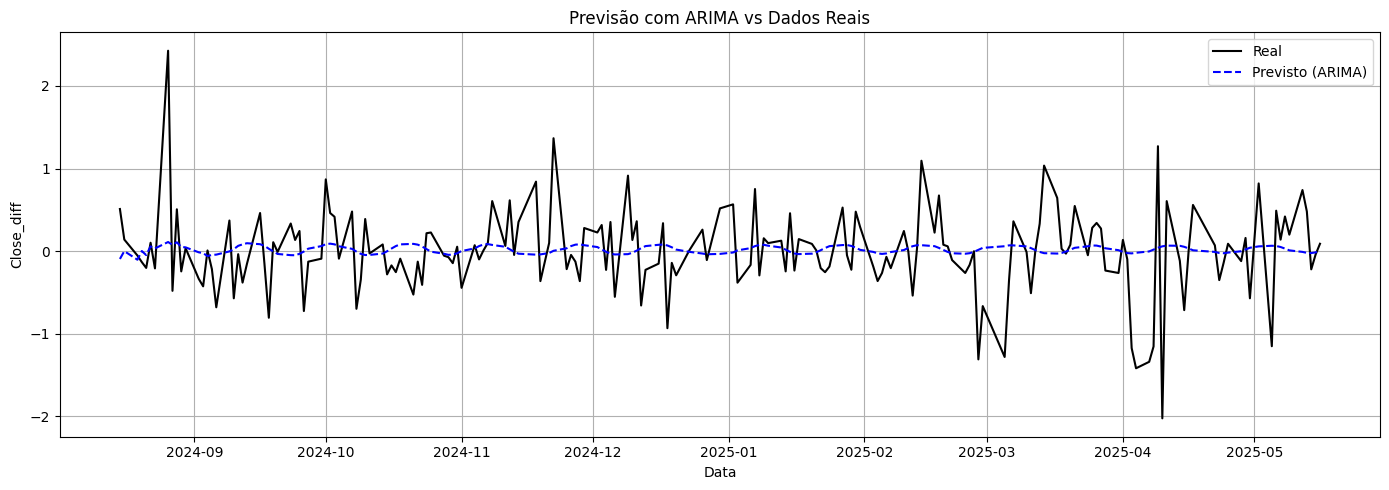

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(df_resultado['Real'], label='Real', color='black')
plt.plot(df_resultado['Previsto'], label='Previsto (ARIMA)', color='blue', linestyle='--')
plt.title('Previsão com ARIMA vs Dados Reais')
plt.xlabel('Data')
plt.ylabel('Close_diff')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


O gráfico mostra a série diferenciada (sem tendência) e a previsão do **ARIMA** nessa mesma escala, que ficou próxima de zero na média, como esperado para uma série diferenciada estacionária.

Os erros **MAE** (0.3622) e **RMSE** (0.5141) indicam que o modelo está razoavelmente ajustado para prever as diferenças, que são valores menores em escala do que os valores originais do preço.

### Prever o preço original (não diferenciado)

Como o objetivo final é prever o preço original (não diferenciado), será necessário fazer a **reversão** da diferenciação para comparar os valores previstos com os reais em escala original. Caso contrário, a avaliação de erro e o gráfico ficarão com base na série diferenciada, o que não é muito intuitivo.


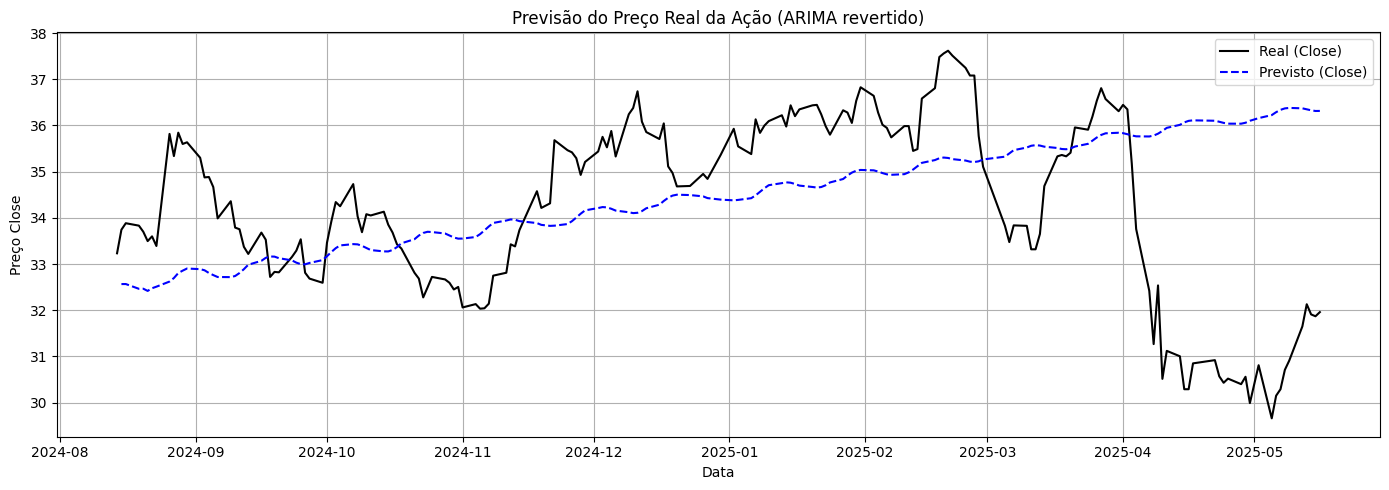

In [ ]:
# Último valor real antes da previsão (último valor antes do conjunto teste)
ultimo_valor_real = df['Close'].iloc[tamanho_treino + tamanho_validacao - 1]

# Reverter a diferenciação acumulando as diferenças previstas e somando o último valor real
previsao_revertida = forecast.cumsum() + ultimo_valor_real

# Obter os valores reais correspondentes ao período da previsão
real = df['Close'].iloc[tamanho_treino + tamanho_validacao:]

df_comparacao = pd.DataFrame({
    'Real_Close': real,
    'Previsto_Close': previsao_revertida
})

plt.figure(figsize=(14,5))
plt.plot(df_comparacao['Real_Close'], label='Real (Close)', color='black')
plt.plot(df_comparacao['Previsto_Close'], label='Previsto (Close)', color='blue', linestyle='--')
plt.title('Previsão do Preço Real da Ação (ARIMA revertido)')
plt.xlabel('Data')
plt.ylabel('Preço Close')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
print(df_comparacao.isna().sum())

Real_Close        0
Previsto_Close    1
dtype: int64


In [ ]:
df_comparacao_clean = df_comparacao.dropna()

In [ ]:
# Avaliar o modelo (na escala original)
mae = mean_absolute_error(df_comparacao_clean['Real_Close'], df_comparacao_clean['Previsto_Close'])
rmse = np.sqrt(mean_squared_error(df_comparacao_clean['Real_Close'], df_comparacao_clean['Previsto_Close']))

print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')

MAE: 1.7436
RMSE: 2.3500


### Análise da Previsão do Preço da Ação com Modelo ARIMA

**Visualização do gráfico:**
O gráfico mostra a série temporal dos preços reais da ação (linha preta) comparada com a previsão gerada pelo modelo ARIMA após a recombinação (linha azul tracejada). Observa-se que o modelo consegue captar a tendência geral do preço no período analisado, especialmente em períodos de estabilidade e crescimento gradual. No entanto, o modelo não acompanha bem as quedas e oscilações bruscas, apresentando uma previsão mais suavizada.

**Métricas de erro:**

* **MAE (Erro Médio Absoluto):** 1.7436
  Isso indica que, em média, o valor previsto pelo modelo difere do valor real em aproximadamente 1.72 unidades monetárias. Considerando o preço da ação, esse erro é razoável, porém pode ser significativo dependendo da volatilidade e da faixa de preço do ativo.
* **RMSE (Raiz do Erro Quadrático Médio):** 2.3500
  Essa métrica penaliza mais os grandes erros e indica que há algumas previsões que se afastam consideravelmente dos valores reais. Isso é coerente com a suavização observada na curva prevista, que não captura bem picos e quedas abruptas.



O modelo ARIMA, após a remoção da tendência para garantir a estacionariedade, consegue prever a trajetória geral do preço da ação, especialmente em períodos mais estáveis. No entanto, sua capacidade de capturar volatilidade e movimentos bruscos ainda é limitada. Isso pode ser devido à natureza do modelo linear ARIMA, que tem dificuldade em lidar com não linearidades e mudanças repentinas típicas do mercado financeiro.

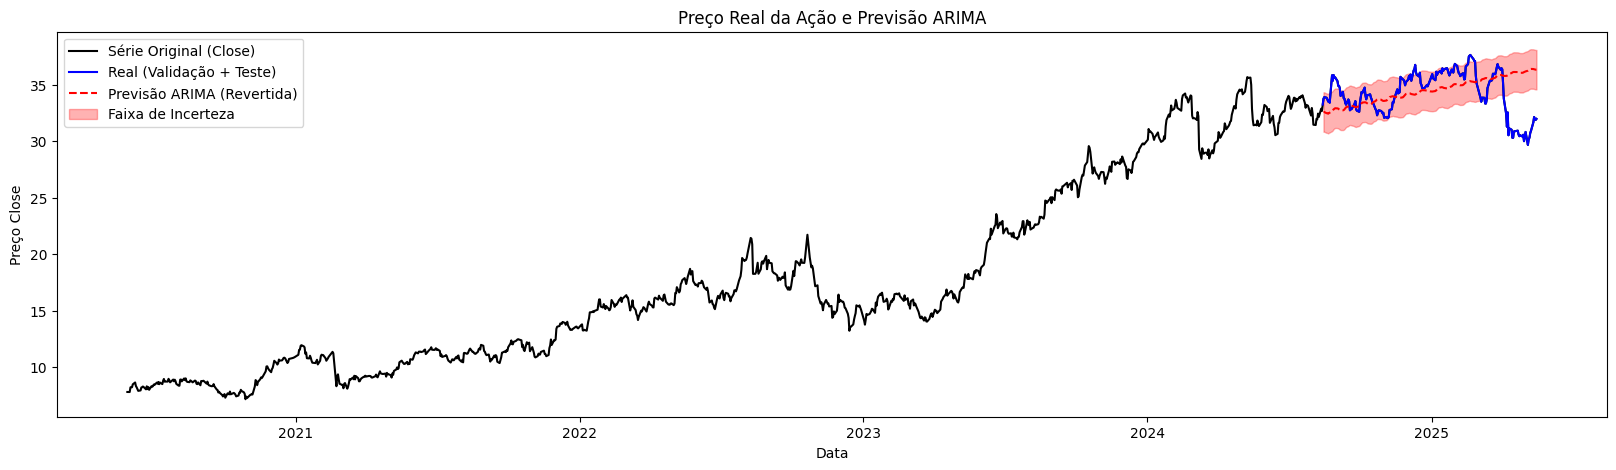

In [ ]:
# Último valor original antes do período de previsão
ultimo_valor_real = df['Close'].iloc[tamanho_treino + tamanho_validacao - 1]

# Previsão acumulada (inverte a diferenciação)
previsao_revertida = forecast.cumsum() + ultimo_valor_real

# Para comparar com os valores reais originais
real = df['Close'].iloc[tamanho_treino + tamanho_validacao:]

desvio = 1.7436

plt.figure(figsize=(20, 5))
plt.plot(df.index, df['Close'], label='Série Original (Close)', color='black')
plt.plot(real.index, real, label='Real (Validação + Teste)', color='blue')
plt.plot(previsao_revertida.index, previsao_revertida, label='Previsão ARIMA (Revertida)', linestyle='--', color='red')
# Faixa sombreada em volta da previsão
plt.fill_between(previsao_revertida.index,
                 previsao_revertida - desvio,
                 previsao_revertida + desvio,
                 color='red', alpha=0.3, label='Faixa de Incerteza')
plt.legend()
plt.title('Preço Real da Ação e Previsão ARIMA')
plt.ylabel('Preço Close')
plt.xlabel('Data')
plt.show()